# Imports and Loading Data

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("cleaned_data.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900.0


Explanation: We import the necessary tools, including StandardScaler for scaling and numpy for transformations. We load the cleaned data from Phase 1.

# One-Hot Encoding

In [24]:
df = pd.get_dummies(df, columns=['MS Zoning', 'Street'], drop_first=True)
df.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Sale Type,Sale Condition,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM,Street_Pave
0,1,526301100,20,141.0,31770,IR1,Lvl,AllPub,Corner,Gtl,...,WD,Normal,215000.0,False,False,False,False,True,False,True
1,2,526350040,20,80.0,11622,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Normal,105000.0,False,False,False,True,False,False,True
2,3,526351010,20,81.0,14267,IR1,Lvl,AllPub,Corner,Gtl,...,WD,Normal,172000.0,False,False,False,False,True,False,True
3,4,526353030,20,93.0,11160,Reg,Lvl,AllPub,Corner,Gtl,...,WD,Normal,244000.0,False,False,False,False,True,False,True
4,5,527105010,60,74.0,13830,IR1,Lvl,AllPub,Inside,Gtl,...,WD,Normal,189900.0,False,False,False,False,True,False,True


Explanation: We use pd.get_dummies() to convert categorical columns into numerical binary columns (0 and 1) so the computer can understand them.

# Ordinal Encoding

In [25]:
quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
df['Exter Qual Num'] = df['Exter Qual'].map(quality_map)

Explanation: We map the 'Exter Qual' (Exterior Quality) from text grades to ordered numbers (1 to 5) because "Excellent" is higher than "Fair".

# Creating Domain Features

In [26]:
df['Price_Per_SF'] = df['SalePrice'] / (df['Gr Liv Area'] + 0.001)
df['House Age'] = df['Yr Sold'] - df['Year Built']

Explanation: We create two new columns. 'Price_Per_SF' is a ratio, where we add 0.001 to avoid dividing by zero. 'House Age' tells us how old the house was when it was sold.

# Creating Interaction Feature

In [27]:
df['Quality_Area_Interact'] = df['Overall Qual'] * df['Gr Liv Area']

Explanation: We multiply 'Overall Qual' by 'Gr Liv Area'. This feature captures the idea that a large house is worth even more if its quality is also high.

# Log Transformation

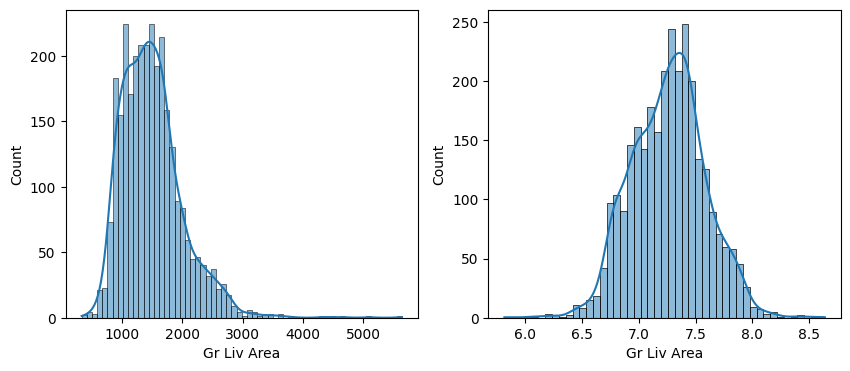

In [28]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Gr Liv Area'], kde=True)

df['Gr Liv Area'] = np.log1p(df['Gr Liv Area'])

plt.subplot(1, 2, 2)
sns.histplot(df['Gr Liv Area'], kde=True)
plt.show()

Explanation: We apply a log transformation to 'Gr Liv Area' to reduce its skewness. The histograms show the distribution before and after the transformation.

# Binning a Column

In [29]:
bins = [0, 10, 40, 200]
labels = ['New', 'Recent', 'Old']
df['House Grade'] = pd.cut(df['House Age'], bins=bins, labels=labels)

Explanation: We group the 'House Age' into three meaningful categories: 'New', 'Recent', and 'Old' using the pd.cut() function.

# Removing Redundant Features

In [30]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
df = df.drop(columns=to_drop)

Explanation: We calculate the correlation between features. If two columns are more than 95% similar (redundant), we drop one of them to simplify the model.

# Feature Scaling

In [31]:
scaler = StandardScaler()
cols_to_scale = ['Lot Area', 'Total Bsmt SF']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

Explanation: We use StandardScaler to rescale 'Lot Area' and 'Total Bsmt SF' so they have a mean of 0 and a standard deviation of 1.

# Saving the Progress

In [33]:
df.to_csv("featured_data.csv", index=False)
print(df.shape)

(2930, 85)


Explanation: We save the final transformed dataset as featured_data.csv to be used in the next phase (Visualisation).